In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from matplotlib_venn import venn2
import scipy as sc
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import fdrcorrection
import warnings
warnings.filterwarnings("ignore")
plt.style.use('/cndd2/jchien/project/Dracheva_Development/script/mplstyle_pec')

BOXPROPS = {
    'boxprops':{'edgecolor':'k','linewidth':0.5},
    'medianprops':{'color':'k','linewidth':0.5},
    'whiskerprops':{'color':'k','linewidth':0.5},
    'capprops':{'color':'k','linewidth':0.5}
}

gene_meta=pd.read_csv('/cndd2/jchien/iGenome/gencodev37/gencode.v37.annotation.intragenic_filter.bed.gz',
                      names=['chr','start','end','gene_id','starnd','tmp','gene_name','fn'],
                      index_col='gene_id', sep='\t')
gene_meta['len']=gene_meta['end']-gene_meta['start']            
genedict_nametoid=dict(zip(gene_meta.gene_name, gene_meta.index))
genedict_idtoname=dict(zip(gene_meta.index, gene_meta.gene_name))

PECmeta=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS.csv',index_col=0)
agedict=dict(zip(PECmeta.index, PECmeta['age']))
sexdict=dict(zip(PECmeta.index, PECmeta['sex']))
perioddict=dict(zip(PECmeta.index, PECmeta['period']))
period_palette={'Infancy': '#F7C98A',
'Early_Childhood': '#F4A154',
'Late_Childhood': '#EF7A3B',
'Adolescence': '#D2614D',
'Adulthood': '#9D4255',
'Late_Adulthood': '#774147'}

period_palette_chip={'Infancy': '#F7C98A',
'Early_Childhood': '#F4A154',
'Late_Childhood': '#EF7A3B',
'Adolescence': '#D2614D',
'Early_Adulthood': '#9D4255',
'Adulthood': '#774147'}

sex_palette={'Female':'#F16090','Male':'#61A3D7'}
celltype_palette={'GLU':'#4faf48','GABA':'#397fba'}
period_order=['Infancy', 'Early_Childhood', 'Late_Childhood', 'Adolescence', 'Adulthood','Late_Adulthood']
# period_order=['infancy', 'earlychildhood', 'latechildhood', 'adolescence', 'adulthood','lateadulthood']
hengdict = {
    'infancy':'Infancy',
    'earlychildhood':'Early_Childhood',
    'latechildhood':'Late_Childhood',
    'adolescence':'Adolescence',
    'adulthood':'Adulthood',
    'lateadulthood':'Late_Adulthood'
    
}

In [2]:
dnaqc=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_DNA_QC.tsv.gz',sep='\t',index_col=0)
rnaqc=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_RNA_QC.tsv.gz',sep='\t',index_col=0)
globalm=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/Individual_globalMethylation_rmSNPs_rmblacklist_10kbbin_c100_autosome_mean.tsv.gz',sep='\t',index_col=0)
globalm=globalm.loc[dnaqc[dnaqc['DNA_passQC']=='True'].index]
rnaexp=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_log2CPM+1.tsv.gz',sep='\t',index_col=0)
# rnaexp=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_TPM.tsv.gz',sep='\t',index_col=0)

rnaexp=rnaexp[rnaqc[rnaqc['RNA_passQC']].index]
# # rnaexp=rnaexp.T
genemcg=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCG_all.tsv.gz',sep='\t',index_col=0)
genemcg=genemcg.loc[dnaqc[dnaqc['DNA_passQC']=='True'].index]
genemch=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCH_all.tsv.gz',sep='\t',index_col=0)
genemch=genemch.loc[dnaqc[dnaqc['DNA_passQC']=='True'].index]

### Examples

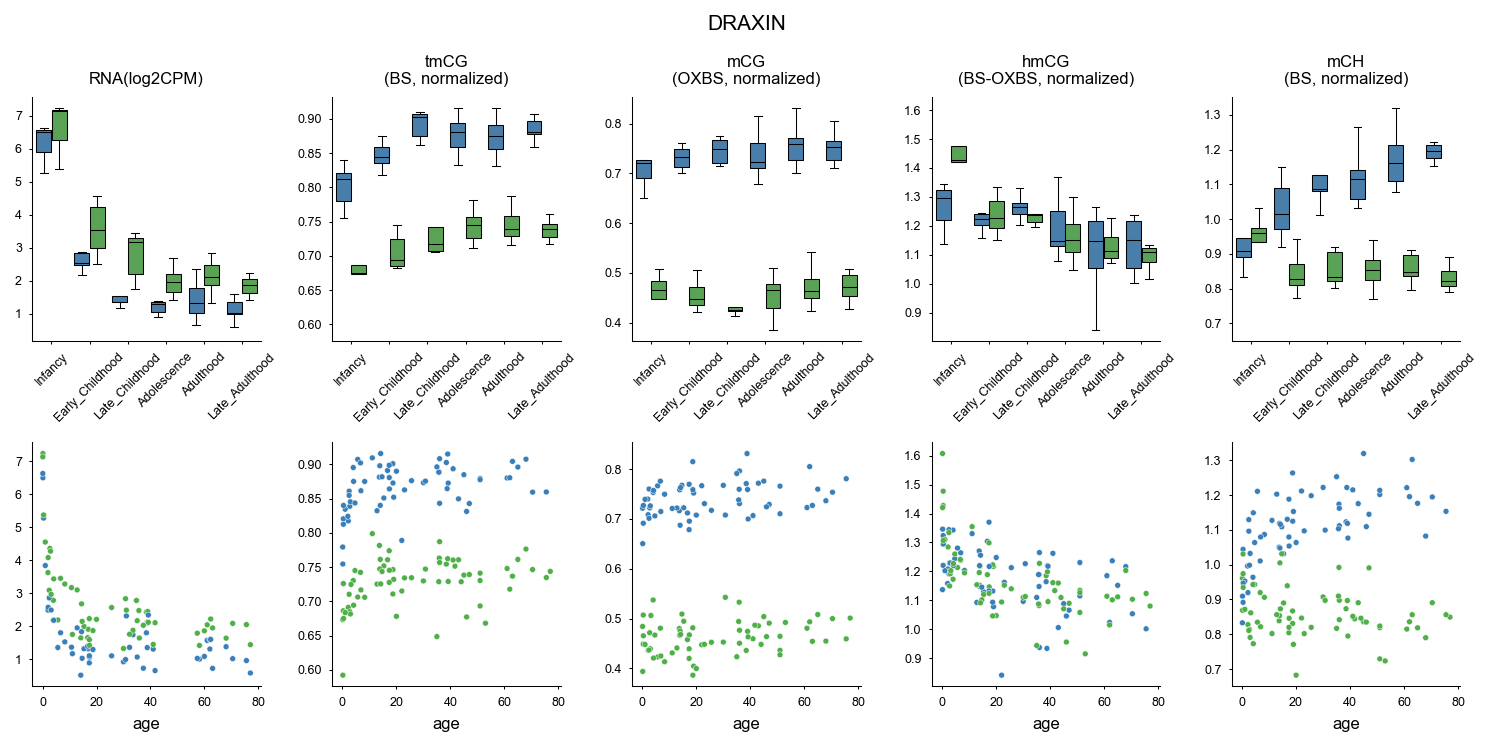

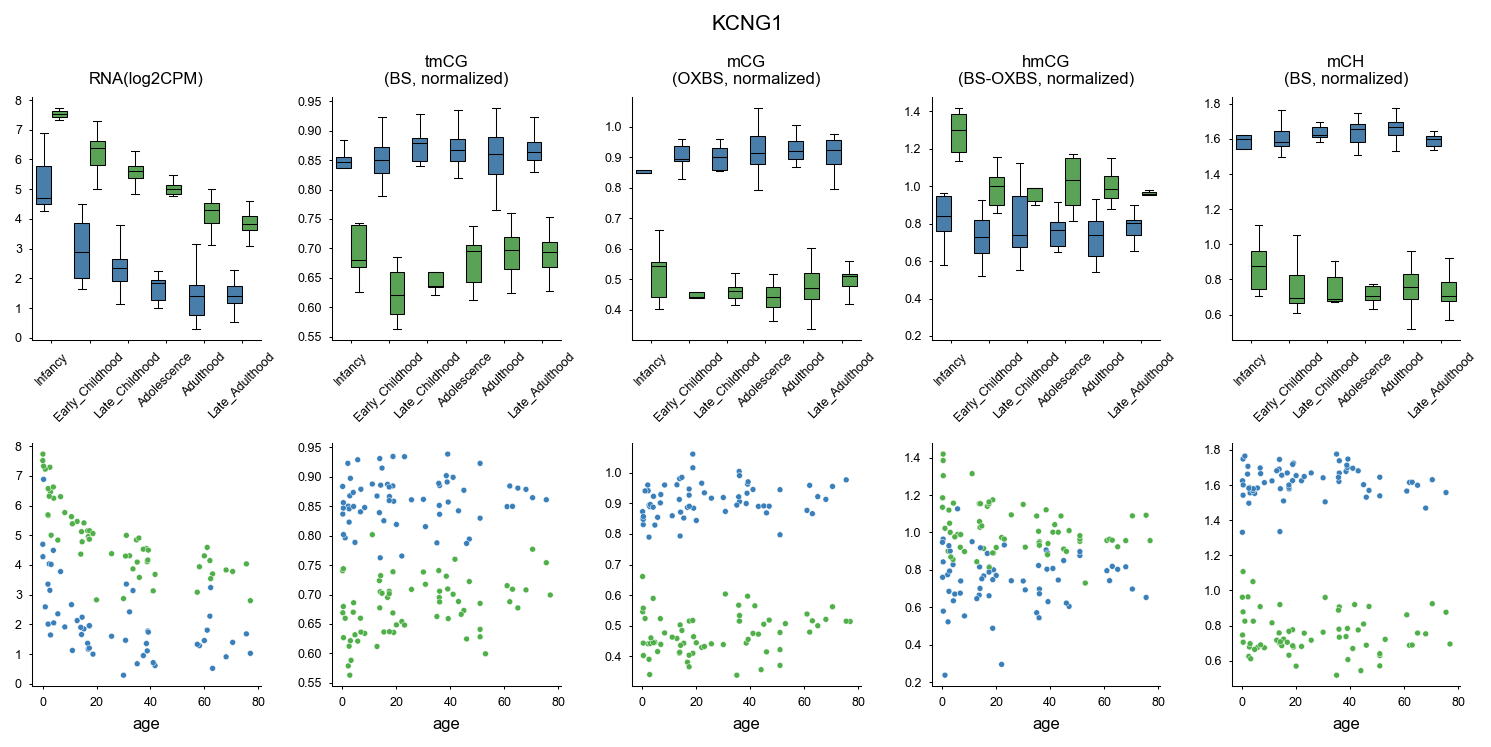

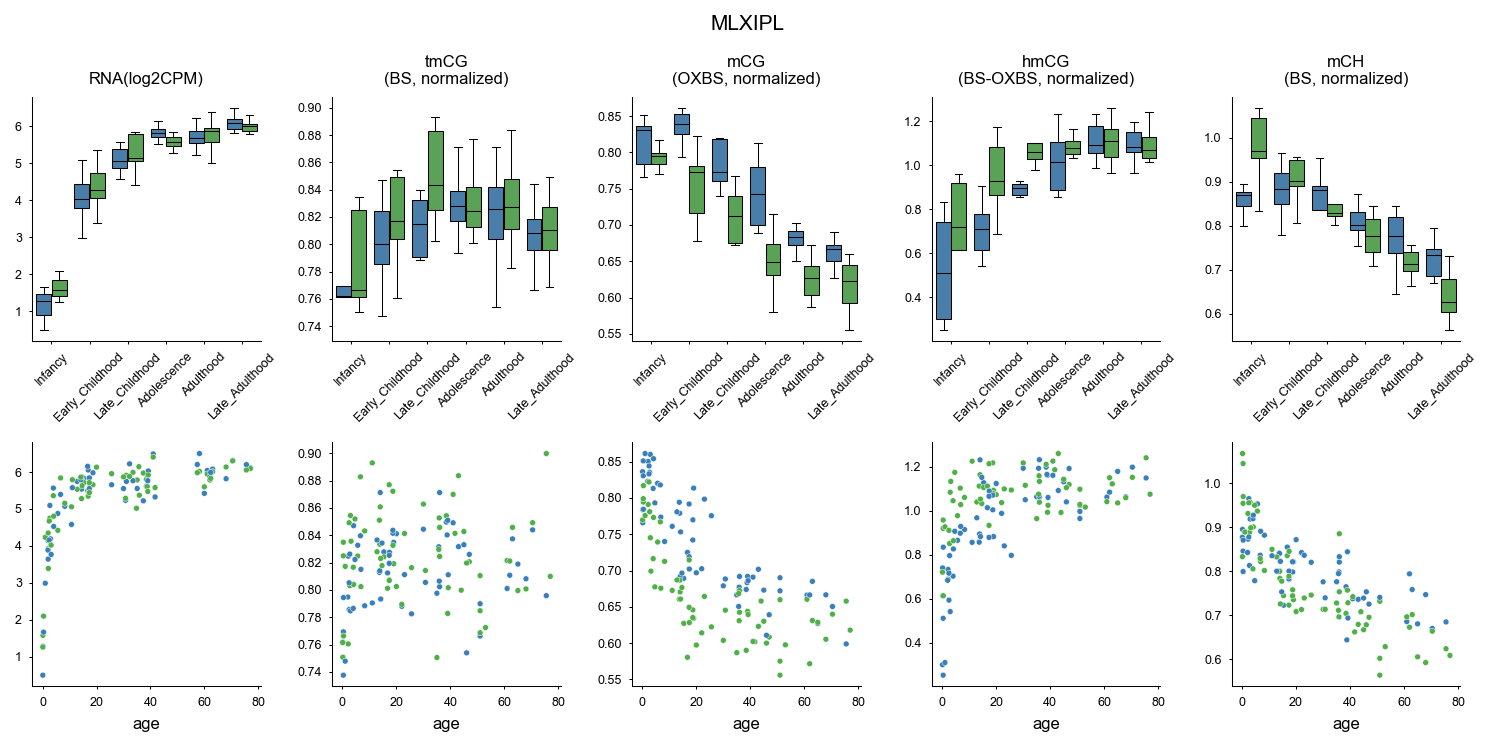

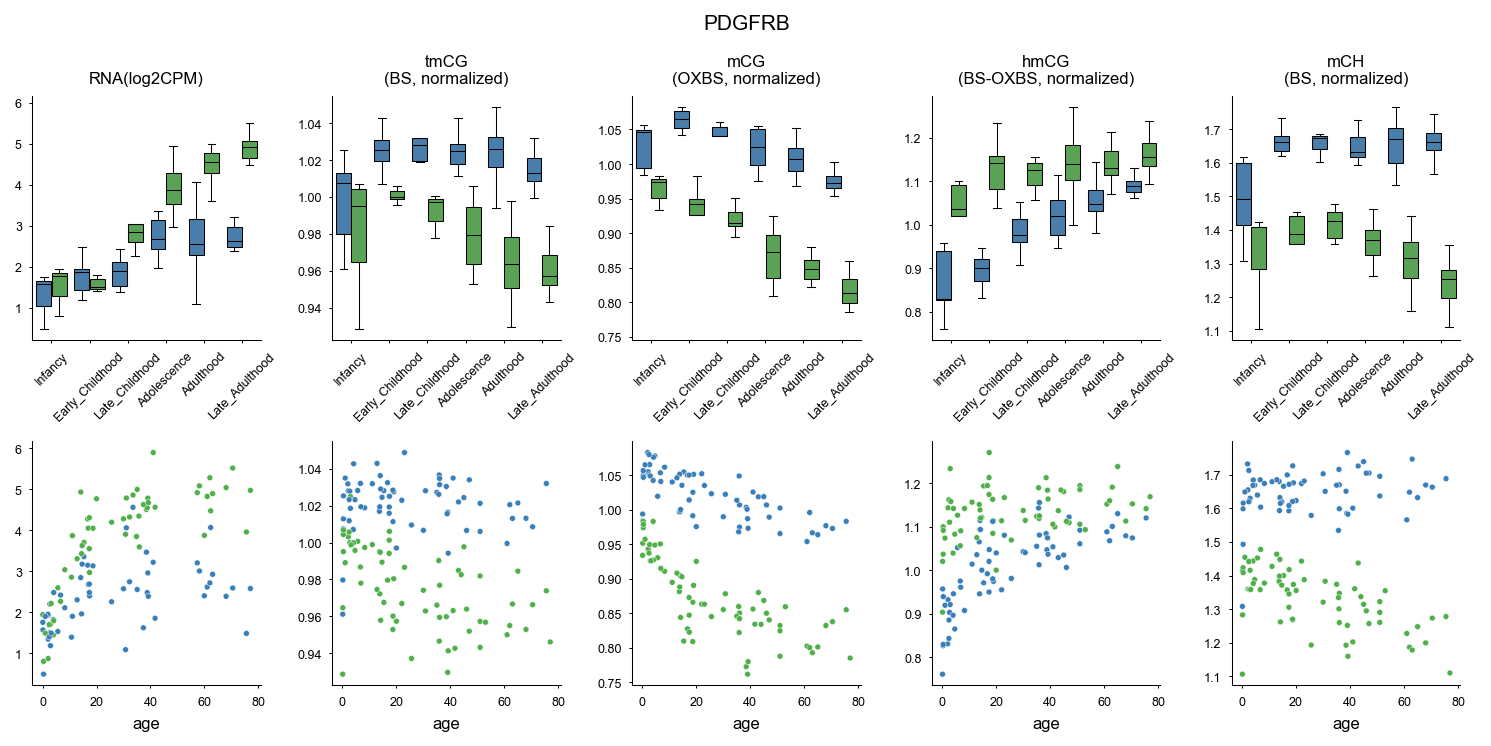

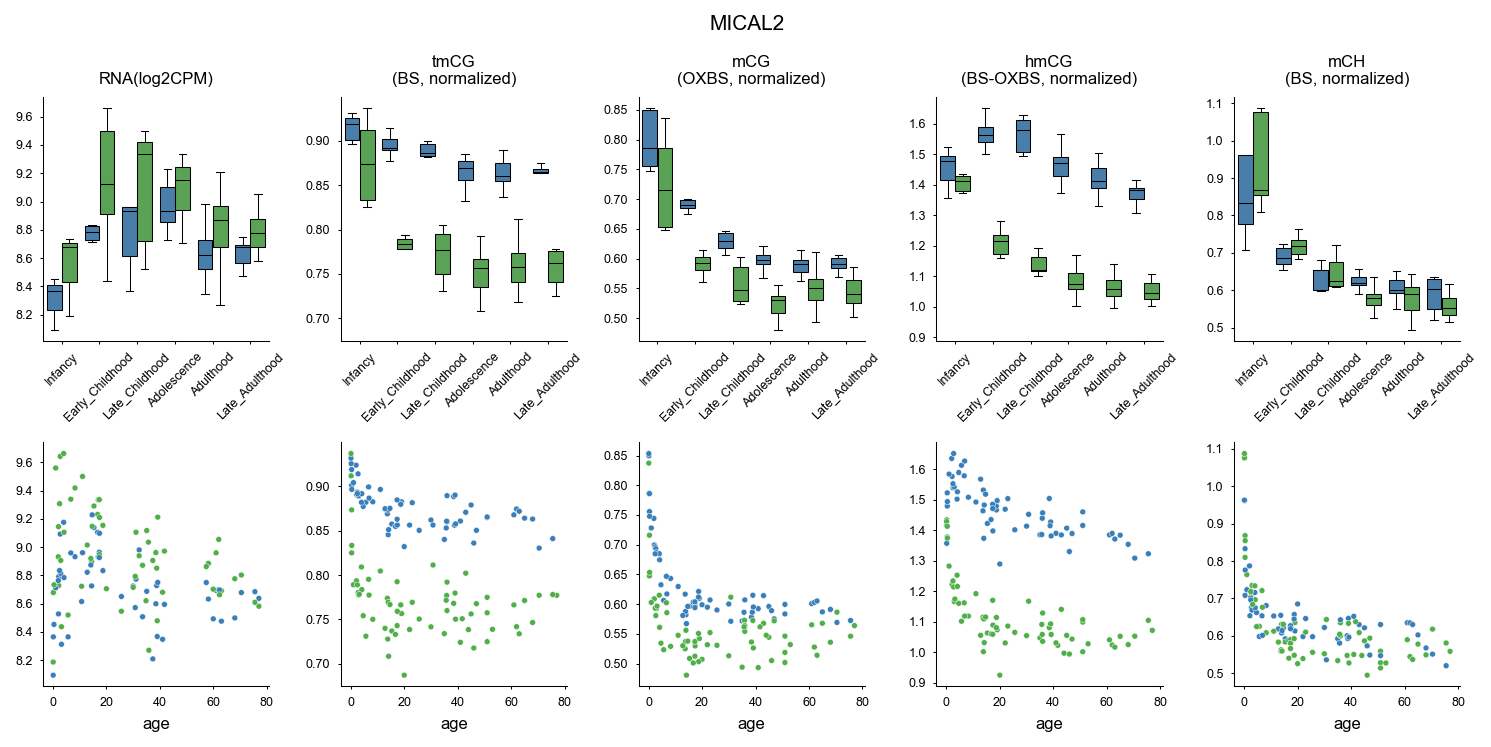

In [9]:
for goi in ['DRAXIN','KCNG1','MLXIPL','PDGFRB','MICAL2']:
    goi = genedict_nametoid[goi]
    
    # RNA
    rnaexp_tmp=rnaexp.T.join(rnaqc[['celltype','age','period']])
    # rnaexp_tmp=rnaexp_tmp[rnaexp_tmp['celltype']=='GLU']
    rnaexp_tmp['log2age']=np.log2(rnaexp_tmp['age'])
    
    # mCG
    globalm_tmp=globalm.join(dnaqc[['donor','celltype','assay','age','period']])
    globalm_tmp=globalm_tmp.pivot(index=['donor','celltype','period'],columns='assay',values='mCGlevel')
    globalm_tmp['hmc']=globalm_tmp['BS']-globalm_tmp['OXBS']
    genemcg_tmp=genemcg.join(dnaqc[['donor','celltype','assay','age','period']]).pivot(index=['donor','celltype','period','age'],columns='assay',values=goi)
    genemcg_tmp['hmc']=genemcg_tmp['BS']-genemcg_tmp['OXBS']
    genemcg_tmp=genemcg_tmp.div(globalm_tmp).reset_index()
    genemcg_tmp['log2age']=np.log2(genemcg_tmp['age'])
    
    # mCH
    globalm_tmp=globalm.join(dnaqc[['donor','celltype','assay','age','period']])
    globalm_tmp=globalm_tmp.pivot(index=['donor','celltype','period'],columns='assay',values='mCHlevel')
    globalm_tmp['hmc']=globalm_tmp['BS']-globalm_tmp['OXBS']
    genemch_tmp=genemch.join(dnaqc[['donor','celltype','assay','age','period']]).pivot(index=['donor','celltype','period','age'],columns='assay',values=goi)
    genemch_tmp['hmc']=genemch_tmp['BS']-genemch_tmp['OXBS']
    genemch_tmp=genemch_tmp.div(globalm_tmp).reset_index()
    genemch_tmp['log2age']=np.log2(genemch_tmp['age'])
    
    fig,axs=plt.subplots(2,5,figsize=(10,5),dpi=150,sharex='row',sharey='col')
    sns.boxplot(x='period',y=goi,hue='celltype',data=rnaexp_tmp,order=period_order,palette=celltype_palette,showfliers=False,ax=axs[0,0],**BOXPROPS)
    sns.boxplot(x='period',y='BS',hue='celltype',data=genemcg_tmp,order=period_order,palette=celltype_palette,showfliers=False,ax=axs[0,1],**BOXPROPS)
    sns.boxplot(x='period',y='OXBS',hue='celltype',data=genemcg_tmp,order=period_order,palette=celltype_palette,showfliers=False,ax=axs[0,2],**BOXPROPS)
    sns.boxplot(x='period',y='hmc',hue='celltype',data=genemcg_tmp,order=period_order,palette=celltype_palette,showfliers=False,ax=axs[0,3],**BOXPROPS)
    sns.boxplot(x='period',y='OXBS',hue='celltype',data=genemch_tmp,order=period_order,palette=celltype_palette,showfliers=False,ax=axs[0,4],**BOXPROPS)
    sns.scatterplot(x='age',y=goi,hue='celltype',data=rnaexp_tmp,palette=celltype_palette,s=8,ax=axs[1,0])
    sns.scatterplot(x='age',y='BS',hue='celltype',data=genemcg_tmp,palette=celltype_palette,s=8,ax=axs[1,1])
    sns.scatterplot(x='age',y='OXBS',hue='celltype',data=genemcg_tmp,palette=celltype_palette,s=8,ax=axs[1,2])
    sns.scatterplot(x='age',y='hmc',hue='celltype',data=genemcg_tmp,palette=celltype_palette,s=8,ax=axs[1,3])
    sns.scatterplot(x='age',y='OXBS',hue='celltype',data=genemch_tmp,palette=celltype_palette,s=8,ax=axs[1,4])
    
    for j in range(2):
        for i in range(5):
            if i==0:
                title='RNA(log2CPM)'
            elif i==1:
                title='tmCG\n(BS, normalized)'
            elif i==2:
                title='mCG\n(OXBS, normalized)'
            elif i==3:
                title='hmCG\n(BS-OXBS, normalized)'
            else:
                title='mCH\n(BS, normalized)'
            if j==0:
                axs[j,i].set_title(title,fontsize=8)
                axs[j,i].tick_params(axis='x',labelrotation=45)
                axs[j,i].set_xlabel('')
            axs[j,i].legend().remove()
            axs[j,i].set_ylabel('')

    plt.suptitle(genedict_idtoname[goi],fontsize=10)
    plt.tight_layout()
    # plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/ageDE_example_{genedict_idtoname[goi]}.pdf',dpi=150)

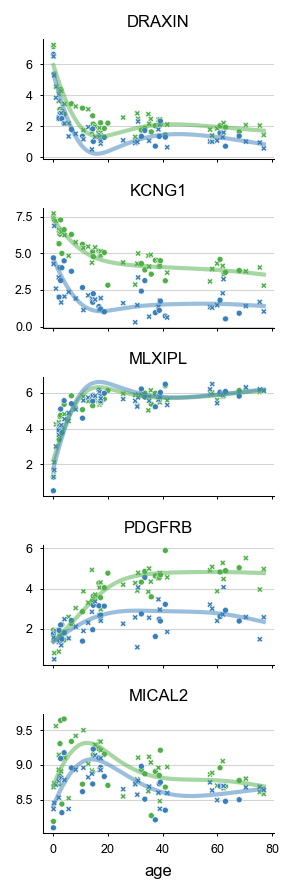

In [11]:
from pygam import LinearGAM,s

gois = ['DRAXIN', 'KCNG1', 'MLXIPL', 'PDGFRB', 'MICAL2']

fig, axs = plt.subplots(len(gois), figsize=(2, 6), dpi=150, sharex=True)
for g, goi in enumerate(gois):
    goi = genedict_nametoid[goi]
    
    for celltype in ['GLU','GABA']:
    
        # RNA
        rnaexp_tmp = rnaexp.T.join(rnaqc[['celltype', 'age', 'period', 'sex']])
        rnaexp_tmp = rnaexp_tmp.reset_index().rename(columns={'index': 'gene_id'}).sort_values('age')
        rnaexp_tmp['log2age'] = np.log2(rnaexp_tmp['age'])
        rnaexp_tmp=rnaexp_tmp[rnaexp_tmp['celltype']==celltype]

        ax = axs[g]
        sns.scatterplot(x='age', y=goi, hue='celltype', data=rnaexp_tmp, style='sex', palette=celltype_palette, s=8, ax=ax)

        # Fit a spline
        x = rnaexp_tmp['age']
        y = rnaexp_tmp[goi]

        n_splines = 10
        n_grid_pts = 200
        weights = np.ones_like(x)
        weights[x > 40] = 0.1
        weights[x > 20] = 0.3  
        weights[x < 3] = 10 
        weights[x < 1] = 15 
        weights[x < 0.5] = 30 

        gam = LinearGAM( s( 0, lam=0.9, n_splines=n_splines), fit_intercept=True).fit(x, y, weights=weights)
        x_smooth = gam.generate_X_grid( term=0, n=n_grid_pts)
        y_smooth = gam.predict(X=x_smooth)

        ax.plot(x_smooth, y_smooth, color=celltype_palette[celltype], linewidth=2, alpha=0.5)
        ax.set_title(genedict_idtoname[goi], fontsize=8)
        ax.legend().remove()
    ax.grid(axis='y')
    ax.set_ylabel('')

plt.tight_layout()

## Correlation between RNA and Methylation within Age Groups

In [16]:
summary=[]
# if 'rnaexp' not in locals():
#     rnaexp=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_TPM.tsv.gz',sep='\t',index_col=0)
#     rnaexp=rnaexp[rnaqc[rnaqc['RNA_passQC']].index].T
for mctype in ['CG','CH']:
    mcfile=pd.read_csv(f'/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_m{mctype}_all.tsv.gz',sep='\t',index_col=0)
    mcfile=mcfile.loc[dnaqc[dnaqc['DNA_passQC']=='True'].index]
    for celltype in ['GABA','GLU']:
        for assay in ['BS','OXBS','hmc']:
            for period in period_order:
                rnaexp_sub=rnaexp.T.loc[rnaqc[(rnaqc['RNA_passQC'])&(rnaqc['celltype']==celltype)&(rnaqc['period']==period)].index].join(rnaqc['donor']).set_index('donor')
                
                if assay !='hmc':
                    mcfile_sub=mcfile.loc[dnaqc[(dnaqc['DNA_passQC']=='True')&(dnaqc['celltype']==celltype)&(dnaqc['period']==period)&(dnaqc['assay']==assay)].index].join(dnaqc['donor']).set_index('donor')
                else:
                    tmp1=mcfile.loc[dnaqc[(dnaqc['DNA_passQC']=='True')&(dnaqc['celltype']==celltype)&(dnaqc['period']==period)&(dnaqc['assay']=='BS')].index].join(dnaqc['donor']).set_index('donor')
                    tmp2=mcfile.loc[dnaqc[(dnaqc['DNA_passQC']=='True')&(dnaqc['celltype']==celltype)&(dnaqc['period']==period)&(dnaqc['assay']=='OXBS')].index].join(dnaqc['donor']).set_index('donor')
                    mcfile_sub=tmp1.subtract(tmp2)
                    del tmp1,tmp2
                    
                # # use only intersection donors
                dois=list(set(rnaexp_sub.index).intersection(set(mcfile_sub.index)))
                rnaexp_sub=rnaexp_sub.loc[dois]
                mcfile_sub=mcfile_sub.loc[dois]    

                gois=list(set(gene_meta[gene_meta['fn']=='protein_coding'].index)\
                        #   .intersection(set(rnaexp_sub.median()[rnaexp_sub.median()>3].index))\
                          .intersection(set(mcfile_sub.median()[mcfile_sub.median()>0].index)))
                df=pd.DataFrame({'rna':np.nanmedian(rnaexp_sub[gois],axis=0),'mc':np.nanmedian(mcfile_sub[gois],axis=0)})
                r,p=sc.stats.spearmanr(df['rna'],df['mc'])
                summary.append({'r':r,'p':p, 'celltype':celltype, 'period':period, 'mctype':mctype, 'assay': assay})
                    
summary=pd.DataFrame(summary) 
_,summary['fdr']=fdrcorrection(summary['p'])


In [27]:
summary['modality']=summary['mctype'] + '_' + summary['assay']
summary = summary[summary['modality'].isin(['CG_BS','CG_OXBS','CG_hmc','CH_BS'])]

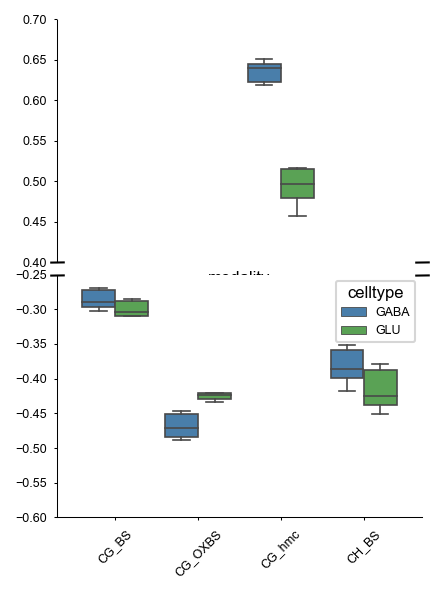

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 4), dpi=150, sharex=True, gridspec_kw={'height_ratios': [1, 1]})

# Define y-axis limits
y1_lim = (0.4, 0.7)
y2_lim = (-0.6, -0.25)

sns.boxplot(
    data=summary,
    x='modality',
    y='r',
    hue='celltype',
    palette=celltype_palette,
    ax=ax1,
    showfliers=False,
    linewidth=0.8
)
ax1.set_ylim(*y1_lim)
ax1.axhline(0, color='grey', linestyle='--', linewidth=0.8, zorder=0)
ax1.legend_.remove()

# Remove x-ticks from the upper plot
ax1.tick_params(axis='x', bottom=False, labelbottom=False)

# Plot on the second axis (lower range)
sns.boxplot(
    data=summary,
    x='modality',
    y='r',
    hue='celltype',
    palette=celltype_palette,
    ax=ax2,
    showfliers=False,
    linewidth=0.8
)
ax2.set_ylim(*y2_lim)
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8, zorder=0)
ax2.tick_params(axis='x', labelrotation=45)

# Hide spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Break marks
d = 0.015  # size of the diagonal lines
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=7, linestyle="none", color='k', mec='k', mew=1, clip_on=False)

# Apply to both axes
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# Labeling and layout
ax2.set_xlabel('', fontsize=10)
ax1.set_ylabel('', fontsize=10)
ax2.set_ylabel('', fontsize=10)
ax2.set_title('', fontsize=12, fontweight='bold')

# Adjust legend
handles, labels = ax2.get_legend_handles_labels()
# fig.legend(handles, labels, title='Cell Type', loc='upper right', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
# plt.savefig('/cndd/hex002/PsychEncode/Figures/corr_RNAvMethy_age_group_box.pdf',dpi=150)   
plt.show()

## Total mCG/mCG/hmCG/Total mCH developmental changes across up/down-regulated genes

In [3]:
DE_genes = pd.read_csv('/cndd/hex002/PsychEncode/rna_seq/genes_trend.csv',index_col = [0])
GLU_expressed_genes = pd.read_csv('/cndd/hex002/PsychEncode/rna_seq/GLU_Infancy_LateAdulthood_FC.csv',index_col=[0])
GABA_expressed_genes = pd.read_csv('/cndd/hex002/PsychEncode/rna_seq/GABA_Infancy_LateAdulthood_FC.csv',index_col=[0])

### Check for Glu

In [4]:
celltype = 'GLU'
DE_genes_sub = DE_genes.loc[celltype]

In [5]:
expressed_gene = GLU_expressed_genes.copy() if celltype == 'GLU' else GABA_expressed_genes.copy()
down_genes = DE_genes_sub[(DE_genes_sub['trend'].isin([0, 1])) & (DE_genes_sub.index == celltype)]['geneID']
up_genes = DE_genes_sub[(DE_genes_sub['trend'].isin([2, 3])) & (DE_genes_sub.index == celltype)]['geneID']
transite_genes = DE_genes_sub[(DE_genes_sub['trend'] == 4) & (DE_genes_sub.index == celltype)]['geneID']

# Assign trend labels
expressed_gene['direction'] = np.select(
    [
        expressed_gene.index.isin(down_genes),
        expressed_gene.index.isin(up_genes),
        expressed_gene.index.isin(transite_genes)
    ],
    ['Down', 'Up', 'Transite'],
    default='non-DEs'
)
expressed_gene = expressed_gene[['direction']]
expressed_gene = expressed_gene[expressed_gene['direction'].isin(['Down','Up','non-DEs'])]

### Total mCG

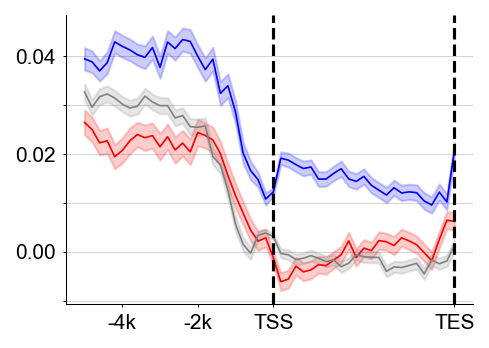

In [11]:
dnadict_nametoage=dict(zip(dnaqc.index, dnaqc.period))
mctype='CG'
df_binc=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/genebody/5kb/genebody_flanking_{celltype}_BS_{mctype}_all.tsv.gz',sep='\t',index_col=['gene_id','bin']).T
# df_binc=df_binc[(dnaqc['DNA_passQC']!='False')]
df_binc=df_binc[(dnaqc['DNA_passQC'] == 'True')]
df_binc['period']=df_binc.index.map(dnadict_nametoage)
df_binc=df_binc.groupby('period').median().T.reset_index(names=['gene_id','bin']).set_index('gene_id')
df_binc['diff']=df_binc['Late_Adulthood']-df_binc['Infancy']
df_binc=df_binc.join(expressed_gene[['direction']],how='right')
df_binc['direction']=df_binc['direction'].fillna('non-DEs')
bin_order=[f'{i}' for i in np.arange(-5000,0,200)]+[f'genebody_{i+1}' for i in range(25)]
df_binc['bin']=pd.Categorical(df_binc['bin'], categories=bin_order,ordered=True)
df_binc=df_binc.sort_values('bin')

plt.figure(figsize=(3.5,2.5),dpi=150)
g=sns.lineplot(x='bin',y='diff',data=df_binc.reset_index(),hue='direction',palette={'Up':'r','Down':'b','non-DEs':'grey'},
            linewidth=0.8,estimator='mean',errorbar='se',legend=False)

plt.grid(axis='y')
plt.ylabel('')
plt.xlabel('')
plt.title('')

plt.axvline(x='genebody_1',c='k',linestyle='--')
plt.axvline(x='genebody_25',c='k',linestyle='--')
tick_positions = ['-4000', '-2000', 'genebody_1', 'genebody_25']
tick_labels = ['-4k', '-2k', 'TSS', 'TES']

plt.xticks(ticks=tick_positions, labels=tick_labels,size = 10)
plt.yticks(size = 10)
for label in g.yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
# plt.savefig(f'/cndd/hex002/PsychEncode/Figures/{celltype}_{mctype}_tmCG_metagene.pdf')

### mCG

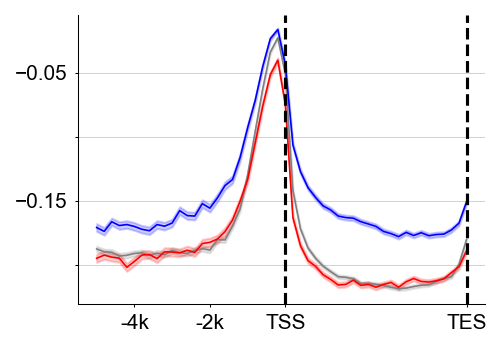

In [ ]:
dnadict_nametoage=dict(zip(dnaqc.index, dnaqc.period))
mctype='CG'
df_binc=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/genebody/5kb/genebody_flanking_{celltype}_OXBS_{mctype}_all.tsv.gz',sep='\t',index_col=['gene_id','bin']).T
df_binc=df_binc[(dnaqc['DNA_passQC'] == 'True')]
df_binc['period']=df_binc.index.map(dnadict_nametoage)
df_binc=df_binc.groupby('period').median().T.reset_index(names=['gene_id','bin']).set_index('gene_id')
df_binc['diff']=df_binc['Late_Adulthood']-df_binc['Infancy']
# df_binc['diff']=df_binc['Adolescence']-df_binc['Early_Childhood']
df_binc=df_binc.join(expressed_gene[['direction']],how='left')
bin_order=[f'{i}' for i in np.arange(-5000,0,200)]+[f'genebody_{i+1}' for i in range(25)]
df_binc['bin']=pd.Categorical(df_binc['bin'], categories=bin_order,ordered=True)
df_binc=df_binc.sort_values('bin')

plt.figure(figsize=(3.5,2.5),dpi=150)
g=sns.lineplot(x='bin',y='diff',data=df_binc.reset_index(),hue='direction',palette={'Up':'r','Down':'b','non-DEs':'grey'},
            linewidth=0.8,estimator='mean',errorbar='se',legend=False)

plt.grid(axis='y')
plt.ylabel('')
plt.xlabel('')
plt.title('')

plt.axvline(x='genebody_1',c='k',linestyle='--')
plt.axvline(x='genebody_25',c='k',linestyle='--')
tick_positions = ['-4000', '-2000', 'genebody_1', 'genebody_25']
tick_labels = ['-4k', '-2k', 'TSS', 'TES']

plt.xticks(ticks=tick_positions, labels=tick_labels,size = 10)
plt.yticks(size = 10)
for label in g.yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
# plt.savefig(f'/cndd/hex002/PsychEncode/Figures/{celltype}_{mctype}_mCG_metagene.pdf')

### hmCG

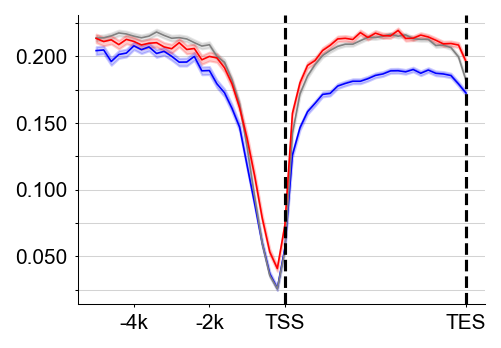

In [26]:
mctype='CG'
tmp1=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/genebody/5kb/genebody_flanking_{celltype}_BS_{mctype}_all.tsv.gz',sep='\t',index_col=['gene_id','bin'])
tmp1=tmp1[list(set(tmp1.columns).intersection(set(dnaqc[dnaqc['DNA_passQC'] == 'True'].index)))]
tmp1.columns=tmp1.columns.str.split('_').str[0]
tmp2=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/genebody/5kb/genebody_flanking_{celltype}_OXBS_{mctype}_all.tsv.gz',sep='\t',index_col=['gene_id','bin'])
tmp2=tmp2[list(set(tmp2.columns).intersection(set(dnaqc[dnaqc['DNA_passQC'] == 'True'].index)))]
tmp2.columns=tmp2.columns.str.split('_').str[0]
df_binc=(tmp1-tmp2).T
df_binc['period']=df_binc.index.map(perioddict)
df_binc=df_binc.groupby('period').median().T.reset_index(names=['gene_id','bin']).set_index('gene_id')
# df_binc['diff']=df_binc['Adolescence']-df_binc['Early_Childhood']
df_binc['diff']=df_binc['Late_Adulthood']-df_binc['Infancy']
df_binc=df_binc.join(expressed_gene[['direction']],how='right')
bin_order=[f'{i}' for i in np.arange(-5000,0,200)]+[f'genebody_{i+1}' for i in range(25)]
df_binc['bin']=pd.Categorical(df_binc['bin'], categories=bin_order,ordered=True)
df_binc=df_binc.sort_values('bin')


plt.figure(figsize=(3.5,2.5),dpi=150)
g=sns.lineplot(x='bin',y='diff',data=df_binc.reset_index(),hue='direction',palette={'Up':'r','Down':'b','non-DEs':'grey'},
            linewidth=0.8,estimator='mean',errorbar='se',legend=False)

plt.grid(axis='y')
plt.ylabel('')
plt.xlabel('')
plt.title('')

plt.axvline(x='genebody_1',c='k',linestyle='--')
plt.axvline(x='genebody_25',c='k',linestyle='--')
tick_positions = ['-4000', '-2000', 'genebody_1', 'genebody_25']
tick_labels = ['-4k', '-2k', 'TSS', 'TES']

plt.xticks(ticks=tick_positions, labels=tick_labels,size = 10)
plt.yticks(size = 10)
for label in g.yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
# plt.savefig(f'/cndd/hex002/PsychEncode/Figures/{celltype}_{mctype}_hmCG_metagene.pdf')

### Total mCH

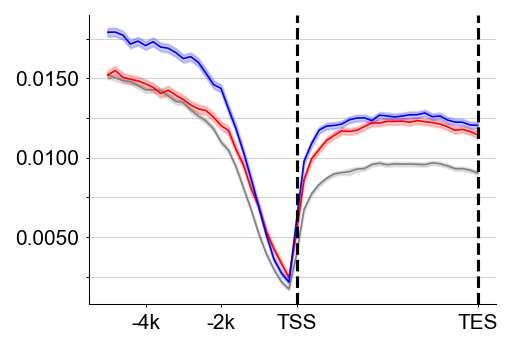

In [27]:
dnadict_nametoage=dict(zip(dnaqc.index, dnaqc.period))
mctype='CH'
df_binc=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/genebody/5kb/genebody_flanking_{celltype}_BS_{mctype}_all.tsv.gz',sep='\t',index_col=['gene_id','bin']).T
df_binc=df_binc[(dnaqc['DNA_passQC']!='False')]
df_binc['period']=df_binc.index.map(dnadict_nametoage)
df_binc=df_binc.groupby('period').median().T.reset_index(names=['gene_id','bin']).set_index('gene_id')
df_binc['diff']=df_binc['Late_Adulthood']-df_binc['Early_Childhood']
df_binc=df_binc.join(expressed_gene[['direction']],how='right')
df_binc['direction']=df_binc['direction'].fillna('non-DEs')
bin_order=[f'{i}' for i in np.arange(-5000,0,200)]+[f'genebody_{i+1}' for i in range(25)]
df_binc['bin']=pd.Categorical(df_binc['bin'], categories=bin_order,ordered=True)
df_binc=df_binc.sort_values('bin')

plt.figure(figsize=(3.5,2.5),dpi=150)
g=sns.lineplot(x='bin',y='diff',data=df_binc.reset_index(),hue='direction',palette={'Up':'r','Down':'b','non-DEs':'grey'},
            linewidth=0.8,estimator='mean',errorbar='se',legend=False)

plt.grid(axis='y')
plt.ylabel('')
plt.xlabel('')
plt.title(f'')
plt.tick_params(axis='x',labelrotation=0)
plt.axvline(x='genebody_1',c='k',linestyle='--')
plt.axvline(x='genebody_25',c='k',linestyle='--')
tick_positions = ['-4000', '-2000', 'genebody_1', 'genebody_25']
tick_labels = ['-4k', '-2k', 'TSS', 'TES']

plt.xticks(ticks=tick_positions, labels=tick_labels,size = 10)
plt.yticks(size = 10)
for label in g.yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
# plt.savefig(f'/cndd/hex002/PsychEncode/Figures/{celltype}_{mctype}_TmCH_metagene.pdf')

## Correlation Between Changes in RNA and Methylation Across Development

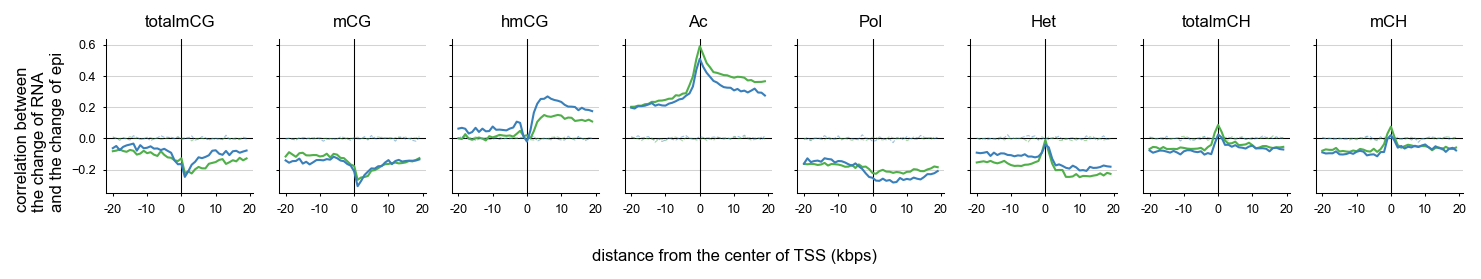

In [29]:
fig,axs = plt.subplots(1,8,figsize=(10,1.8),dpi=150,sharey=True)
for i,assay in enumerate(['totalmCG','mCG','hmCG','Ac','Pol','Het','totalmCH','mCH']):
    for celltype in ['GLU','GABA']:
    
        if 'm' not in assay:
            celltype2 = celltype.replace('LU','lu')
            bin_summary = pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/mCvsRNA/corr_change_of_{assay}_vs_RNA_{celltype2}_TSSflanking.tsv.gz',sep='\t',index_col=0)
        else:
            bin_summary = pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/mCvsRNA/corr_change_of_{assay}_vs_RNA_{celltype}_TSSflanking.tsv.gz',sep='\t',index_col=0)
        

        ax=axs[i]
        ax.axvline(x=0,c='k',linewidth=0.5, zorder=1)
        ax.axhline(y=0,c='k',linewidth=0.5, zorder=1)
        ax.plot(bin_summary['r'],c=celltype_palette[celltype],linewidth=1, zorder=10)
        ax.plot(bin_summary['r_shuffle'],c=celltype_palette[celltype],linewidth=0.5,linestyle='--',alpha=0.5, zorder=10)
    ax.set_xticks([-20000,-10000,0,10000,20000],['-20','-10','0','10','20'])
    ax.set_title(assay)
    
    ax.grid(axis='y')
fig.supxlabel('distance from the center of TSS (kbps)',fontsize=8)
fig.supylabel(f'correlation between \nthe change of RNA \nand the change of epi',fontsize=8)
plt.tight_layout()
# plt.savefig('/cndd2/jchien/project/Dracheva_Development/Figure/corr_change_RNAvsallepi_sharey.pdf',dpi=150)